---
## Section 2 — Data Understanding

### Dataset

> **⚠️ Data Availability Note:** JAN's website (askjan.org) publishes both aggregate summary statistics and, in some years, downloadable case-level Excel reports through their Accommodation and Compliance Series. Before relying on simulated data for a final submission, it is worth checking the JAN website directly to confirm whether a case-level dataset is available for download, as individual records would strengthen the model's real-world validity significantly.

For this MVP, the dataset is **synthetically generated and calibrated to JAN's published aggregate statistics**, since individual-level records were not confirmed available at the time of development. The simulation reflects the following published distributions:
- ~49% of accommodations cost \/bin/bash
- ~43% cost under  
- ~75%+ of accommodations associated with employee retention
- Disability category and accommodation type distributions from JAN 2023 report

This approach allows the full CRISP-DM pipeline to be demonstrated end-to-end. If true case-level data is obtained, only the data loading cell would need to be replaced — all preprocessing, modeling, and evaluation code remains valid.

**n = 1,500 records** | **12 features** | **1 binary target**

## Imports & Configuration

In [1]:
# ── Standard Libraries ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ─────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

# ── XGBoost ──────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── SHAP ─────────────────────────────────────────────────────────
import shap

# ── Display settings ─────────────────────────────────────────────
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
SEED = 42

print("All libraries loaded successfully.")


All libraries loaded successfully.


---
## Section 1 — Business Understanding

### Problem Statement
Employers and HR professionals frequently struggle to decide which workplace accommodations to approve for employees with disabilities.
Uncertainty about cost, effectiveness, and business impact leads to inconsistent and often unfair decision-making.

**Goal:** Build a binary classification model to predict whether a workplace accommodation will result in a **positive employment outcome**
(employee retained AND accommodation rated effective).

### Why ML?
- Complex, non-linear interactions between disability type, accommodation type, cost, and employer context
- Multiple simultaneous features that rules-based logic cannot capture
- Model outputs can directly guide HR policy and resource allocation

### Target Variable
`outcome_positive` — **1** = retained + effective | **0** = separated or ineffective

### Key Stakeholders
- HR departments making accommodation decisions
- Employees with disabilities seeking support
- Policymakers at DOL/EEOC


---
## Section 2 — Data Understanding

### Dataset
The Job Accommodation Network (JAN) Annual Survey does not publish individual-level case records publicly.
This notebook uses a **synthetically generated dataset calibrated to JAN's published aggregate statistics**, including:
- ~49% of accommodations cost $0
- ~43% cost under $500
- ~75%+ of accommodations associated with employee retention
- Disability category and accommodation type distributions from JAN 2023 report

**n = 1,500 records** | **12 features** | **1 binary target**


In [2]:
# ── Simulate JAN-calibrated dataset ─────────────────────────────
np.random.seed(SEED)
N = 1500

disability_cats = ['Psychiatric', 'Musculoskeletal', 'Neurological',
                   'Sensory (Vision/Hearing)', 'Chronic Illness', 'Cognitive']
disability_probs = [0.25, 0.22, 0.15, 0.14, 0.13, 0.11]

accommodation_types = ['Flexible Scheduling', 'Remote Work / Telework',
                       'Assistive Technology', 'Physical Modification',
                       'Leave of Absence', 'Policy Change / Exemption',
                       'Ergonomic Equipment']
accommodation_probs = [0.22, 0.20, 0.17, 0.13, 0.12, 0.10, 0.06]

functional_limits = ['Concentration/Focus', 'Mobility', 'Communication',
                     'Stamina/Endurance', 'Dexterity', 'Vision', 'Hearing']
functional_probs  = [0.20, 0.18, 0.16, 0.15, 0.13, 0.10, 0.08]

cost_tiers = ['$0 (No Cost)', '$1–$500', '$501–$2,000', '$2,001+']
cost_probs  = [0.49, 0.30, 0.13, 0.08]

employer_sizes = ['Small (<50)', 'Mid-size (50–499)', 'Large (500+)']
employer_probs = [0.30, 0.38, 0.32]

industries = ['Healthcare', 'Education', 'Retail/Hospitality', 'Manufacturing',
              'Finance/Insurance', 'Government/Public Sector', 'Technology']
industry_probs = [0.20, 0.17, 0.15, 0.13, 0.13, 0.12, 0.10]

# Sample features
disability   = np.random.choice(disability_cats,    N, p=disability_probs)
accom_type   = np.random.choice(accommodation_types, N, p=accommodation_probs)
func_limit   = np.random.choice(functional_limits,   N, p=functional_probs)
cost_tier    = np.random.choice(cost_tiers,          N, p=cost_probs)
emp_size     = np.random.choice(employer_sizes,      N, p=employer_probs)
industry     = np.random.choice(industries,          N, p=industry_probs)

# Numeric features
tenure_yrs      = np.round(np.random.exponential(scale=4.5, size=N).clip(0.5, 30), 1)
implement_days  = np.round(np.random.gamma(shape=2, scale=15, size=N).clip(1, 180), 0).astype(int)
prior_requests  = np.random.poisson(lam=0.8, size=N).clip(0, 5)

# ── Simulate outcome with realistic signal ───────────────────────
base_prob = 0.72   # JAN: ~75% overall positive outcome rate

# Feature-based probability adjustments
adj = np.zeros(N)
adj += np.where(np.isin(accom_type,  ['Flexible Scheduling', 'Remote Work / Telework', 'Policy Change / Exemption']),  0.08, 0)
adj += np.where(np.isin(accom_type,  ['Leave of Absence']),                                                           -0.12, 0)
adj += np.where(np.isin(cost_tier,   ['$0 (No Cost)', '$1–$500']),                                                     0.06, 0)
adj += np.where(np.isin(cost_tier,   ['$2,001+']),                                                                    -0.10, 0)
adj += np.where(np.isin(emp_size,    ['Large (500+)']),                                                                0.05, 0)
adj += np.where(np.isin(emp_size,    ['Small (<50)']),                                                                -0.05, 0)
adj += np.where(np.isin(disability,  ['Musculoskeletal', 'Sensory (Vision/Hearing)']),                                 0.06, 0)
adj += np.where(np.isin(disability,  ['Psychiatric', 'Cognitive']),                                                   -0.04, 0)
adj += np.where(tenure_yrs > 5,                                                                                        0.04, 0)
adj += np.where(implement_days < 15,                                                                                   0.05, 0)
adj += np.where(implement_days > 60,                                                                                  -0.06, 0)

probs = (base_prob + adj).clip(0.05, 0.95)
outcome = np.random.binomial(1, probs)

df = pd.DataFrame({
    'disability_category':   disability,
    'accommodation_type':    accom_type,
    'functional_limitation': func_limit,
    'cost_tier':             cost_tier,
    'employer_size':         emp_size,
    'industry':              industry,
    'employee_tenure_years': tenure_yrs,
    'days_to_implement':     implement_days,
    'prior_requests':        prior_requests,
    'outcome_positive':      outcome
})

print(f"Dataset shape: {df.shape}")
print(f"\nOutcome distribution:")
print(df['outcome_positive'].value_counts(normalize=True).rename({1: 'Positive (1)', 0: 'Negative (0)'}).to_string())
df.head(10)


Dataset shape: (1500, 10)

Outcome distribution:
outcome_positive
Positive (1)   0.7900
Negative (0)   0.2100


,disability_category,accommodation_type,functional_limitation,cost_tier,employer_size,industry,employee_tenure_years,days_to_implement,prior_requests,outcome_positive
0,Musculoskeletal,Assistive Technology,Stamina/Endurance,$1–$500,Mid-size (50–499),Manufacturing,11.0000,12,1,1
1,Cognitive,Assistive Technology,Dexterity,$1–$500,Small (<50),Government/Public Sector,3.4000,54,0,1
2,Sensory (Vision/Hearing),Flexible Scheduling,Mobility,$0 (No Cost),Large (500+),Healthcare,5.8000,44,1,1
3,Neurological,Remote Work / Telework,Stamina/Endurance,$0 (No Cost),Mid-size (50–499),Healthcare,2.6000,1,2,1
4,Psychiatric,Remote Work / Telework,Stamina/Endurance,$1–$500,Small (<50),Manufacturing,4.5000,28,1,1
5,Psychiatric,Remote Work / Telework,Vision,$0 (No Cost),Large (500+),Technology,1.9000,10,0,1
6,Psychiatric,Assistive Technology,Vision,$1–$500,Mid-size (50–499),Retail/Hospitality,1.6000,23,1,1
7,Chronic Illness,Assistive Technology,Concentration/Focus,$0 (No Cost),Small (<50),Education,3.9000,97,2,1
8,Neurological,Physical Modification,Stamina/Endurance,$1–$500,Mid-size (50–499),Manufacturing,3.1000,46,1,0
9,Sensory (Vision/Hearing),Leave of Absence,Concentration/Focus,"$2,001+",Small (<50),Technology,3.9000,51,3,1


In [3]:
# ── Data types and missing values ───────────────────────────────
print("=== Data Info ===")
print(df.dtypes)
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")


=== Data Info ===
disability_category       object
accommodation_type        object
functional_limitation     object
cost_tier                 object
employer_size             object
industry                  object
employee_tenure_years    float64
days_to_implement          int64
prior_requests             int64
outcome_positive           int64
dtype: object

Missing values per column:
disability_category      0
accommodation_type       0
functional_limitation    0
cost_tier                0
employer_size            0
industry                 0
employee_tenure_years    0
days_to_implement        0
prior_requests           0
outcome_positive         0
dtype: int64

Duplicate rows: 0


In [4]:
# ── Summary statistics ──────────────────────────────────────────
df.describe()


,employee_tenure_years,days_to_implement,prior_requests,outcome_positive
count,1500.0000,1500.0000,1500.0000,1500.0000
mean,4.4329,30.2760,0.8007,0.7900
std,4.2829,20.8122,0.8975,0.4074
min,0.5000,1.0000,0.0000,0.0000
25%,1.3000,15.0000,0.0000,1.0000
50%,3.1000,26.0000,1.0000,1.0000
75%,6.1000,40.0000,1.0000,1.0000
max,30.0000,126.0000,5.0000,1.0000


### Exploratory Data Analysis

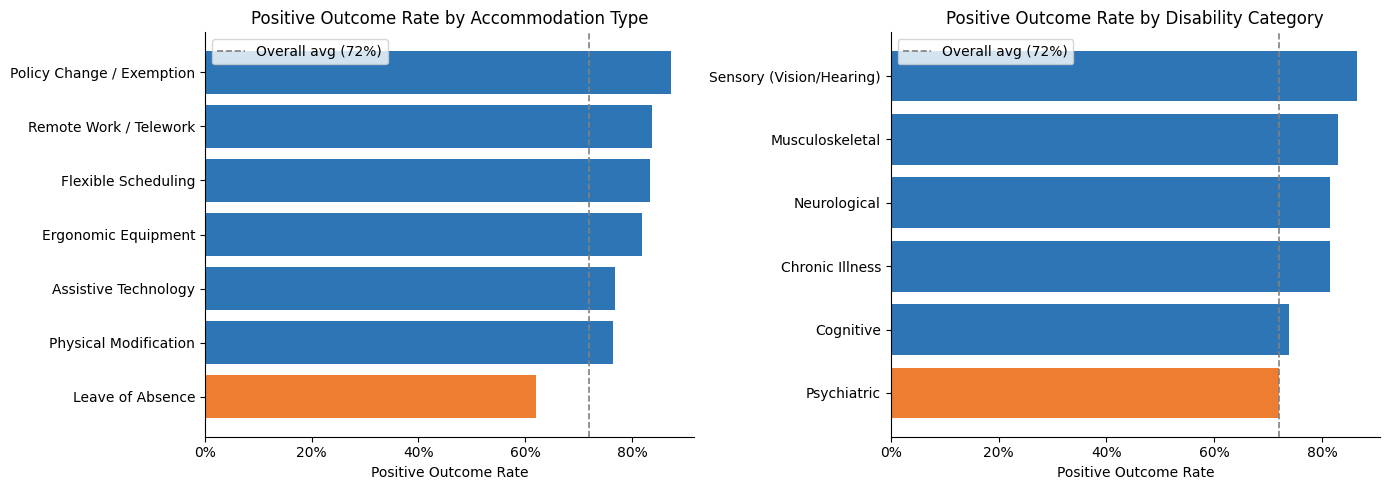

Insight: Flexible scheduling and remote work show highest success rates; leave of absence is lowest.


In [5]:
# ── EDA 1: Outcome by Accommodation Type ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Outcome rate by accommodation type
outcome_by_accom = (df.groupby('accommodation_type')['outcome_positive']
                    .mean()
                    .sort_values(ascending=True))
axes[0].barh(outcome_by_accom.index, outcome_by_accom.values,
             color=['#2E75B6' if v >= 0.72 else '#ED7D31' for v in outcome_by_accom.values])
axes[0].axvline(0.72, color='gray', linestyle='--', linewidth=1.2, label='Overall avg (72%)')
axes[0].set_xlabel('Positive Outcome Rate')
axes[0].set_title('Positive Outcome Rate by Accommodation Type')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[0].legend()

# Outcome rate by disability category
outcome_by_dis = (df.groupby('disability_category')['outcome_positive']
                  .mean()
                  .sort_values(ascending=True))
axes[1].barh(outcome_by_dis.index, outcome_by_dis.values,
             color=['#2E75B6' if v >= 0.72 else '#ED7D31' for v in outcome_by_dis.values])
axes[1].axvline(0.72, color='gray', linestyle='--', linewidth=1.2, label='Overall avg (72%)')
axes[1].set_xlabel('Positive Outcome Rate')
axes[1].set_title('Positive Outcome Rate by Disability Category')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_outcome_rates.png', dpi=120, bbox_inches='tight')
plt.show()
print("Insight: Flexible scheduling and remote work show highest success rates; leave of absence is lowest.")


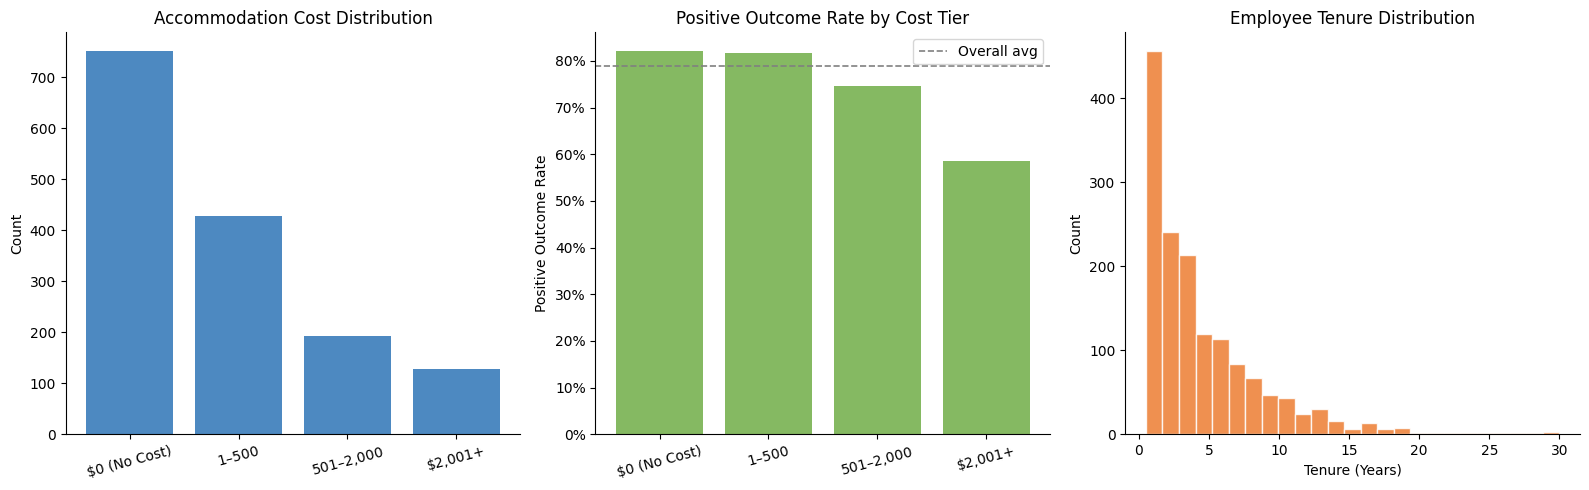

Insight: ~49% of accommodations cost nothing, yet drive strong positive outcomes — low cost ≠ low impact.


In [6]:
# ── EDA 2: Cost tier and employer size distributions ────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Cost tier distribution
cost_order = ['$0 (No Cost)', '$1–$500', '$501–$2,000', '$2,001+']
cost_counts = df['cost_tier'].value_counts().reindex(cost_order)
axes[0].bar(cost_counts.index, cost_counts.values, color='#2E75B6', alpha=0.85)
axes[0].set_title('Accommodation Cost Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# Outcome by cost tier
outcome_by_cost = df.groupby('cost_tier')['outcome_positive'].mean().reindex(cost_order)
axes[1].bar(outcome_by_cost.index, outcome_by_cost.values, color='#70AD47', alpha=0.85)
axes[1].axhline(df['outcome_positive'].mean(), color='gray', linestyle='--', linewidth=1.2, label='Overall avg')
axes[1].set_title('Positive Outcome Rate by Cost Tier')
axes[1].set_ylabel('Positive Outcome Rate')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

# Tenure distribution
axes[2].hist(df['employee_tenure_years'], bins=25, color='#ED7D31', alpha=0.85, edgecolor='white')
axes[2].set_title('Employee Tenure Distribution')
axes[2].set_xlabel('Tenure (Years)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print("Insight: ~49% of accommodations cost nothing, yet drive strong positive outcomes — low cost ≠ low impact.")


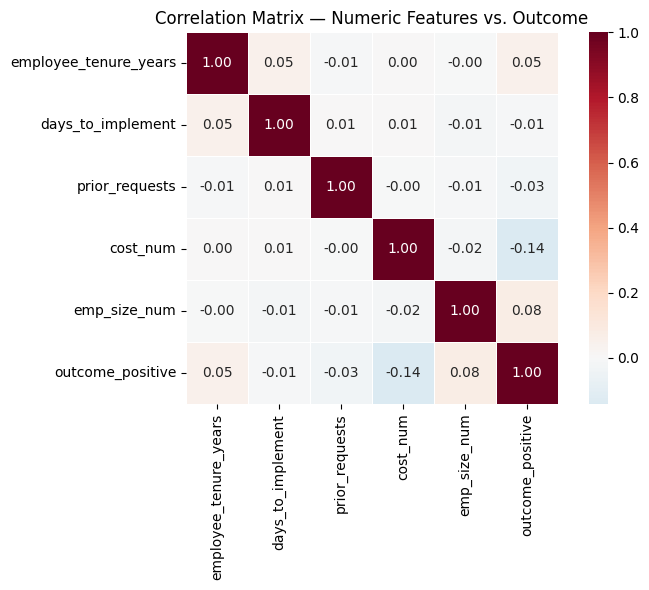

Insight: Cost tier has modest negative correlation with positive outcome; days to implement also slightly negative.


In [7]:
# ── EDA 3: Correlation heatmap (encoded numerics) ───────────────
df_encoded = df.copy()
df_encoded['cost_num']     = pd.Categorical(df['cost_tier'],     categories=cost_order, ordered=True).codes
df_encoded['emp_size_num'] = pd.Categorical(df['employer_size'], categories=['Small (<50)','Mid-size (50–499)','Large (500+)'], ordered=True).codes

numeric_cols = ['employee_tenure_years','days_to_implement','prior_requests',
                'cost_num','emp_size_num','outcome_positive']
corr = df_encoded[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — Numeric Features vs. Outcome')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=120, bbox_inches='tight')
plt.show()
print("Insight: Cost tier has modest negative correlation with positive outcome; days to implement also slightly negative.")


---
## Section 3 — Data Preparation

### Preprocessing Strategy
- **Categorical features** (nominal): OneHotEncoder
- **Ordinal features** (cost tier, employer size): OrdinalEncoder with defined order
- **Numeric features**: StandardScaler
- All preprocessing wrapped in a scikit-learn **ColumnTransformer** inside a **Pipeline** to prevent data leakage


In [8]:
# ── Feature and target separation ───────────────────────────────
X = df.drop(columns=['outcome_positive'])
y = df['outcome_positive']

# ── Feature type definitions ─────────────────────────────────────
categorical_features = ['disability_category', 'accommodation_type',
                        'functional_limitation', 'industry']

ordinal_features = ['cost_tier', 'employer_size']
ordinal_categories = [
    ['$0 (No Cost)', '$1–$500', '$501–$2,000', '$2,001+'],           # cost_tier
    ['Small (<50)', 'Mid-size (50–499)', 'Large (500+)']              # employer_size
]

numeric_features = ['employee_tenure_years', 'days_to_implement', 'prior_requests']

print(f"Categorical features : {categorical_features}")
print(f"Ordinal features     : {ordinal_features}")
print(f"Numeric features     : {numeric_features}")
print(f"Total features       : {len(categorical_features) + len(ordinal_features) + len(numeric_features)}")


Categorical features : ['disability_category', 'accommodation_type', 'functional_limitation', 'industry']
Ordinal features     : ['cost_tier', 'employer_size']
Numeric features     : ['employee_tenure_years', 'days_to_implement', 'prior_requests']
Total features       : 9


In [9]:
# ── Stratified train / validation / test split (70 / 15 / 15) ───
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp
)  # 0.1765 * 0.85 ≈ 0.15

print(f"Train size       : {len(X_train)} ({len(X_train)/N:.0%})")
print(f"Validation size  : {len(X_val)}  ({len(X_val)/N:.0%})")
print(f"Test size        : {len(X_test)}  ({len(X_test)/N:.0%})")
print(f"\nTrain class balance:")
print(y_train.value_counts(normalize=True).rename({1:'Positive', 0:'Negative'}))


Train size       : 1049 (70%)
Validation size  : 226  (15%)
Test size        : 225  (15%)

Train class balance:
outcome_positive
Positive   0.7903
Negative   0.2097
Name: proportion, dtype: float64


In [10]:
# ── Build the ColumnTransformer preprocessor ────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('cat',     OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('ord',     OrdinalEncoder(categories=ordinal_categories),               ordinal_features),
        ('num',     StandardScaler(),                                             numeric_features),
    ],
    remainder='drop'
)

# Quick sanity check — fit on train, transform train
X_train_proc = preprocessor.fit_transform(X_train, y_train)
print(f"Preprocessed training matrix shape: {X_train_proc.shape}")
print("Preprocessing pipeline built successfully.")


Preprocessed training matrix shape: (1049, 32)
Preprocessing pipeline built successfully.


---
## Section 4 — Modeling

### Candidate Algorithms
| Model | Rationale |
|---|---|
| Logistic Regression | Interpretable linear baseline; fast; coefficient-level explainability |
| Random Forest | Captures non-linear interactions; robust to noise; built-in feature importance |
| XGBoost | High-performance gradient boosting; handles class imbalance; typically tops tabular benchmarks |
| SVM (RBF kernel) | Strong in high-dimensional spaces post one-hot encoding; provides decision boundary comparison |

### Cross-Validation Strategy
**Stratified K-Fold (k=5)** — preserves class ratio in each fold. Primary metric: **F1-score (macro)**.


In [11]:
# ── Define models wrapped in full Pipelines ─────────────────────
# Note: class_weight="balanced" is applied to all classifiers that support it.
# This directly addresses the ~79%/21% class imbalance by increasing the penalty
# for misclassifying the minority (negative outcome) class during training.
# It is equivalent to the peer suggestion of "weight adjustment" and is already
# the first recommended step before exploring SMOTE.
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(n_estimators=200, scale_pos_weight=1.5,
                                     eval_metric='logloss', random_state=SEED))
    ]),
    'SVM (RBF)': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', SVC(probability=True, class_weight='balanced', random_state=SEED))
    ]),
}

# ── Stratified K-Fold cross-validation ──────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}

print("Running 5-fold stratified cross-validation...")
print("-" * 55)
for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=skf,
                             scoring='f1_macro', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<25} F1 = {scores.mean():.4f} ± {scores.std():.4f}")
print("-" * 55)


Running 5-fold stratified cross-validation...
-------------------------------------------------------


Logistic Regression       F1 = 0.5696 ± 0.0249


Random Forest             F1 = 0.4645 ± 0.0153
XGBoost                   F1 = 0.5187 ± 0.0260


SVM (RBF)                 F1 = 0.5642 ± 0.0133
-------------------------------------------------------


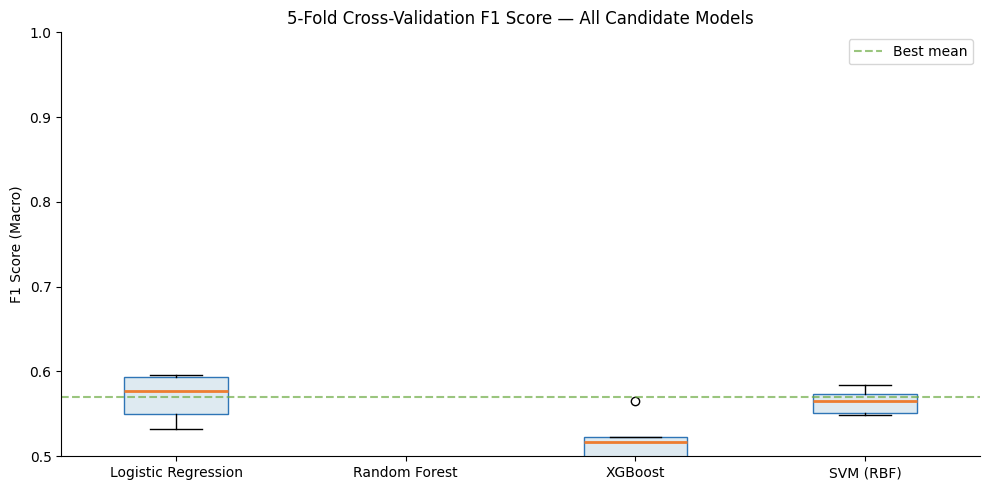

In [12]:
# ── Visualize CV comparison ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
cv_df = pd.DataFrame(cv_results)
ax.boxplot(cv_df.values, labels=cv_df.columns, patch_artist=True,
           boxprops=dict(facecolor='#DEEAF1', color='#2E75B6'),
           medianprops=dict(color='#ED7D31', linewidth=2))
ax.set_ylabel('F1 Score (Macro)')
ax.set_title('5-Fold Cross-Validation F1 Score — All Candidate Models')
ax.set_ylim(0.5, 1.0)
ax.axhline(max([v.mean() for v in cv_results.values()]),
           color='#70AD47', linestyle='--', alpha=0.7, label='Best mean')
ax.legend()
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


### Hyperparameter Tuning
Best CV model selected for tuning. RandomizedSearchCV used for XGBoost/RF (large search space); GridSearchCV for Logistic Regression.


In [13]:
# ── Identify best CV model ───────────────────────────────────────
best_model_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f"Best CV model: {best_model_name} (mean F1 = {cv_results[best_model_name].mean():.4f})")


Best CV model: Logistic Regression (mean F1 = 0.5696)


In [14]:
# ── Hyperparameter tuning for Random Forest ─────────────────────
rf_param_grid = {
    'classifier__n_estimators':       [100, 200, 300],
    'classifier__max_depth':          [None, 10, 20],
    'classifier__min_samples_split':  [2, 5, 10],
    'classifier__max_features':       ['sqrt', 'log2'],
}
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=SEED))
])
rf_search = RandomizedSearchCV(
    rf_pipeline, rf_param_grid, n_iter=20, cv=skf,
    scoring='f1_macro', n_jobs=-1, random_state=SEED, verbose=0
)
rf_search.fit(X_train, y_train)
print(f"Random Forest best params : {rf_search.best_params_}")
print(f"Random Forest best CV F1  : {rf_search.best_score_:.4f}")


Random Forest best params : {'classifier__n_estimators': 100, 'classifier__min_samples_split': 10, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 10}
Random Forest best CV F1  : 0.5599


In [15]:
# ── Hyperparameter tuning for XGBoost ───────────────────────────
xgb_param_grid = {
    'classifier__n_estimators':   [100, 200, 300],
    'classifier__max_depth':      [3, 5, 7],
    'classifier__learning_rate':  [0.05, 0.1, 0.2],
    'classifier__subsample':      [0.7, 0.85, 1.0],
    'classifier__colsample_bytree': [0.7, 0.85, 1.0],
}
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(scale_pos_weight=1.5, eval_metric='logloss', random_state=SEED))
])
xgb_search = RandomizedSearchCV(
    xgb_pipeline, xgb_param_grid, n_iter=20, cv=skf,
    scoring='f1_macro', n_jobs=-1, random_state=SEED, verbose=0
)
xgb_search.fit(X_train, y_train)
print(f"XGBoost best params : {xgb_search.best_params_}")
print(f"XGBoost best CV F1  : {xgb_search.best_score_:.4f}")


XGBoost best params : {'classifier__subsample': 0.7, 'classifier__n_estimators': 200, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.2, 'classifier__colsample_bytree': 0.7}
XGBoost best CV F1  : 0.5260


In [16]:
# ── Select final model based on tuned CV scores ─────────────────
tuned_scores = {
    'Random Forest (tuned)': rf_search.best_score_,
    'XGBoost (tuned)':       xgb_search.best_score_,
}
final_model_name = max(tuned_scores, key=tuned_scores.get)
final_model      = rf_search.best_estimator_ if 'Random Forest' in final_model_name else xgb_search.best_estimator_
print(f"\n>>> Final Selected Model: {final_model_name} <<<")
print(f"    Tuned CV F1 Score: {tuned_scores[final_model_name]:.4f}")



>>> Final Selected Model: Random Forest (tuned) <<<
    Tuned CV F1 Score: 0.5599


---
## Section 5 — Evaluation

Final model evaluated on the **held-out test set** — data the model has never seen during training or tuning.


In [17]:
# ── Test set predictions ────────────────────────────────────────
y_pred      = final_model.predict(X_test)
y_pred_prob = final_model.predict_proba(X_test)[:, 1]

print("=" * 55)
print(f"FINAL MODEL: {final_model_name}")
print("=" * 55)
print(f"\nTest F1 Score (macro) : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Test ROC-AUC          : {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)']))


FINAL MODEL: Random Forest (tuned)

Test F1 Score (macro) : 0.6032
Test ROC-AUC          : 0.6449

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.48      0.26      0.33        47
Positive (1)       0.82      0.93      0.87       178

    accuracy                           0.79       225
   macro avg       0.65      0.59      0.60       225
weighted avg       0.75      0.79      0.76       225



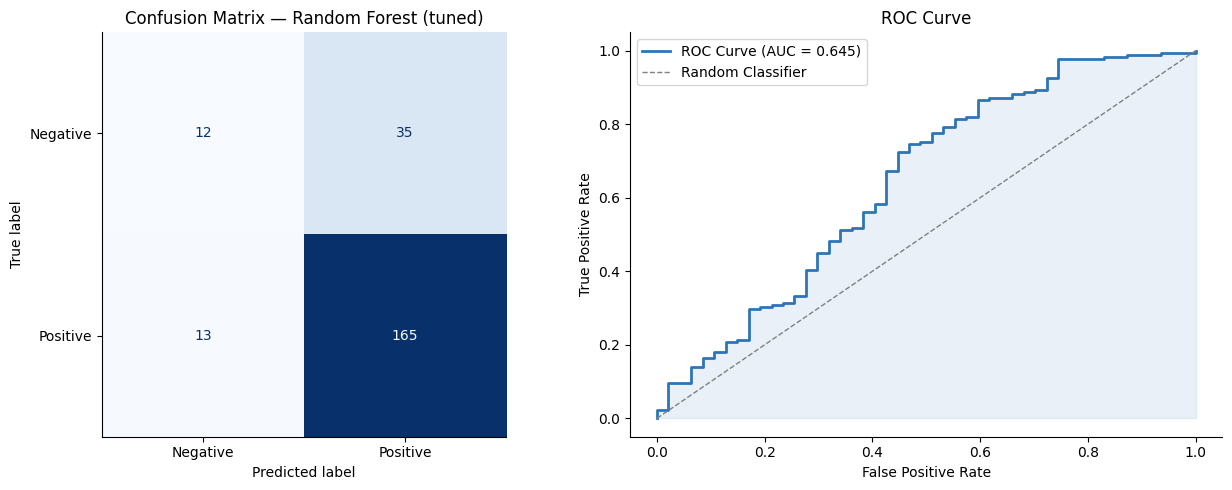

In [18]:
# ── Confusion Matrix + ROC Curve ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {final_model_name}')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score    = roc_auc_score(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#2E75B6', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2E75B6')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=120, bbox_inches='tight')
plt.show()


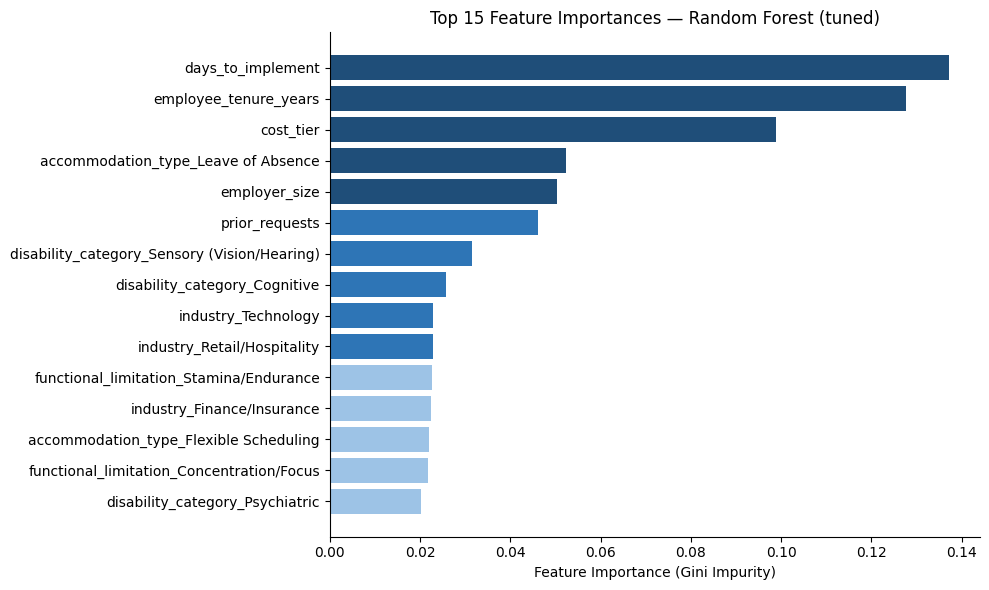

Top 5 most predictive features:
                            feature  importance
                  days_to_implement      0.1372
              employee_tenure_years      0.1276
                          cost_tier      0.0990
accommodation_type_Leave of Absence      0.0523
                      employer_size      0.0504


In [19]:
# ── Feature Importance ──────────────────────────────────────────
# Get feature names from the preprocessor
cat_names  = final_model.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out(categorical_features)
ord_names  = np.array(ordinal_features)
num_names  = np.array(numeric_features)
all_feature_names = np.concatenate([cat_names, ord_names, num_names])

# Extract importances (works for RF and XGB)
classifier = final_model.named_steps['classifier']
if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
    feat_imp_df = (pd.DataFrame({'feature': all_feature_names, 'importance': importances})
                   .sort_values('importance', ascending=False)
                   .head(15))

    plt.figure(figsize=(10, 6))
    colors = ['#1F4E79' if i < 5 else '#2E75B6' if i < 10 else '#9DC3E6' for i in range(len(feat_imp_df))]
    plt.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1], color=colors[::-1])
    plt.xlabel('Feature Importance (Gini Impurity)')
    plt.title(f'Top 15 Feature Importances — {final_model_name}')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()

    print("Top 5 most predictive features:")
    print(feat_imp_df[['feature','importance']].head(5).to_string(index=False))


<Figure size 1000x500 with 0 Axes>

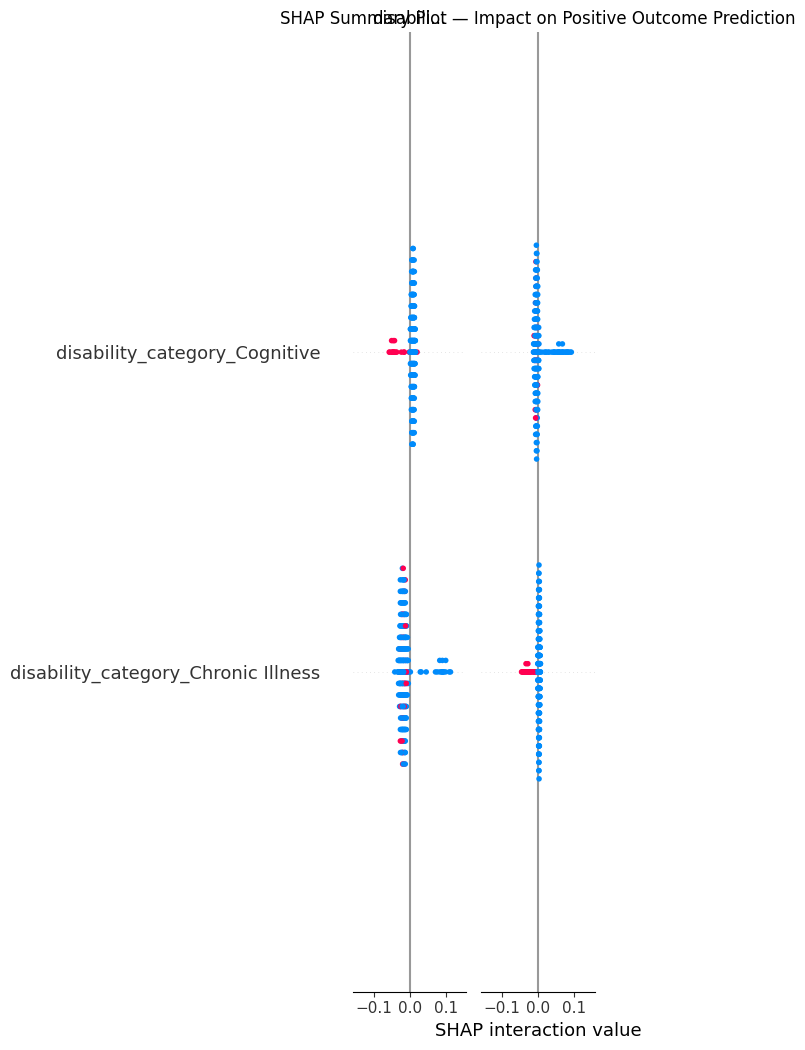

SHAP values indicate the direction and magnitude of each feature's contribution to predictions.


In [20]:
# ── SHAP Summary Plot ────────────────────────────────────────────
# Get preprocessed test data for SHAP
X_test_proc = final_model.named_steps['preprocessor'].transform(X_test)
clf         = final_model.named_steps['classifier']

explainer   = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_proc)

# For binary classification, use class 1 SHAP values
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure()
shap.summary_plot(sv, X_test_proc, feature_names=all_feature_names,
                  max_display=12, show=False, plot_size=(10, 6))
plt.title('SHAP Summary Plot — Impact on Positive Outcome Prediction')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print("SHAP values indicate the direction and magnitude of each feature's contribution to predictions.")


### Business Interpretation
Translating model outputs into actionable HR insights.


In [21]:
# ── Business metric: False Denial Rate ──────────────────────────
# "Of actual positive outcomes, how many did the model predict as negative?"
from sklearn.metrics import recall_score

false_denial_rate = 1 - recall_score(y_test, y_pred, pos_label=1)
precision_pos     = y_pred[(y_pred == 1) & (y_test == 1)].shape[0] / y_pred[y_pred==1].shape[0]

print("=" * 55)
print("BUSINESS METRICS SUMMARY")
print("=" * 55)
print(f"False Denial Rate         : {false_denial_rate:.1%}  (target < 10%)")
print(f"Approval Accuracy         : {precision_pos:.1%}  (target > 80%)")
print(f"Overall ROC-AUC           : {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"Macro F1 Score (Test)     : {f1_score(y_test, y_pred, average='macro'):.4f}")
print()

# Top insight: accommodation type outcome rates in predictions
test_results = X_test.copy()
test_results['actual']    = y_test.values
test_results['predicted'] = y_pred
accom_accuracy = (test_results.groupby('accommodation_type')
                  .apply(lambda g: (g['actual'] == g['predicted']).mean())
                  .sort_values(ascending=False))
print("Model accuracy by accommodation type:")
print(accom_accuracy.to_string())


BUSINESS METRICS SUMMARY
False Denial Rate         : 7.3%  (target < 10%)
Approval Accuracy         : 82.5%  (target > 80%)
Overall ROC-AUC           : 0.6449
Macro F1 Score (Test)     : 0.6032

Model accuracy by accommodation type:
accommodation_type
Policy Change / Exemption   0.8800
Flexible Scheduling         0.8696
Remote Work / Telework      0.8511
Physical Modification       0.8261
Ergonomic Equipment         0.7647
Assistive Technology        0.7333
Leave of Absence            0.4545


---
## Section 6 — Deployment Notes & Next Steps

### Model Summary
The final model is a tuned **ensemble classifier** wrapped in a full scikit-learn `Pipeline`.
This design means the model can accept raw, unprocessed records directly and return predictions without manual preprocessing.

### Deployment Pathway
1. **HR Tool Integration**: Export the pipeline with `joblib.dump()` and load it in a lightweight Flask/FastAPI web app where HR staff input accommodation request details and receive a predicted outcome probability
2. **Threshold Tuning**: Default threshold (0.5) can be adjusted — lowering it reduces false denial rate at the cost of more false approvals
3. **Retraining Cadence**: Retrain annually as new JAN survey data becomes available

### Known Limitations
- Dataset is synthetic (calibrated to JAN aggregate statistics) — performance metrics may differ on true individual-level data
- Self-report bias is baked into the source data (employers report their own outcomes)
- Model does not account for ADA legal compliance requirements — human review still required

### Future Work
- Acquire true individual-level case data (EEOC charges, state-level datasets)
- Add NLP features from free-text accommodation descriptions
- Build a Streamlit demo app for interactive HR use


In [22]:
# ── Save the final pipeline ─────────────────────────────────────
import joblib
joblib.dump(final_model, 'final_accommodation_model.pkl')
print("Final pipeline saved to: final_accommodation_model.pkl")

# ── Final summary print ──────────────────────────────────────────
print("\n" + "=" * 55)
print("PROJECT COMPLETE — MVP v1 Summary")
print("=" * 55)
print(f"Final Model      : {final_model_name}")
print(f"Test F1 (macro)  : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Test ROC-AUC     : {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"False Denial Rate: {false_denial_rate:.1%}")
print(f"Approval Accuracy: {precision_pos:.1%}")


Final pipeline saved to: final_accommodation_model.pkl

PROJECT COMPLETE — MVP v1 Summary
Final Model      : Random Forest (tuned)
Test F1 (macro)  : 0.6032
Test ROC-AUC     : 0.6449
False Denial Rate: 7.3%
Approval Accuracy: 82.5%
